# Block 3 — Deep Learning with Time Series Data: Modern Architectures

**Goals for this block:**
- Understand differences between LSTM, GRU and TCN.
- Connect receptive field (TCN) and context window (Transformer/RNN) to the sliding-window setup.
- Run a forecasting with TCN and (optional: Transformer/ARIMA/Prophet).

## 0. Setup & Environment

In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
tf.config.set_logical_device_configuration(gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=6500)])

import torch
assert torch.cuda.is_available()
torch.cuda.set_per_process_memory_fraction(0.3)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

from darts.dataprocessing.transformers import Scaler
from darts.utils.missing_values import fill_missing_values
from darts import TimeSeries


the preprocessing function from previous blocks

In [ ]:
def preprocessing_data_with_DARTS(series,
                      resample_freq='h', agg_method='mean',
                      missing_strategy='linear', 
                      scaling_method='standard',
                      train_ratio=0.7, val_ratio=0.15):
    """
    Complete time series preprocessing pipeline using Darts library.
        
    Returns: train, train_y, val, val_y, test, test_y, scaler
    """

    # 1. Handle missing values
    filled_series = fill_missing_values(series, method=missing_strategy)

    # 2. Resample data
    resampled_series = filled_series.resample(resample_freq, method=agg_method)
    
    # 3. Time-aware split
    
    # Calculate split points
    total_len = len(resampled_series)
    train_end = int(total_len * train_ratio)
    val_end = int(total_len * (train_ratio + val_ratio))
    
    # Split the series
    train_series = resampled_series[:train_end]
    val_series = resampled_series[train_end:val_end]
    test_series = resampled_series[val_end:]

    # 4. Scaling (fit only on training data)
    if scaling_method == 'standard':
        scaler = StandardScaler()
    elif scaling_method == 'minmax':
        scaler = MinMaxScaler()
    elif scaling_method == 'robust':
        scaler = RobustScaler()
    else:
        raise ValueError(f"Unsupported scaling method: {scaling_method}")
        
    scaler = Scaler(scaler)
    
    # Fit on training data and transform all sets
    scaler.fit(train_series)
    train_scaled = scaler.transform(train_series)
    val_scaled = scaler.transform(val_series)
    test_scaled = scaler.transform(test_series)
    
    # 5. WINDOWING
    ######## NOT NEEDED WITH DARTS MODELS ##########

    return train_scaled, val_scaled, test_scaled, scaler

## Loading Elctricity Consumption Dataset

Electricity Consumption of **households & SMEs (low voltage)** and **businesses & services (medium voltage)** in the city of Zurich, with values recorded every **15 minutes**.

The electricity consumption is combined with weather measurements recorded by **three different stations in the city of Zurich** with a hourly frequency . 

Both dataset sources are updated continuously, but this dataset only retrains values between **2015-01-01** and **2022-08-31**. The time index was converted from CET time zone to UTC.

Components Descriptions:

`Value_NE5` : Households & SMEs electricity consumption (low voltage, grid level 7) in kWh

`Value_NE7` : Business and services electricity consumption (medium voltage, grid level 5) in kWh

`Hr [%Hr]` : Relative humidity

`RainDur [min]` : Duration of precipitation (divided by 4 for conversion from hourly to quarter-hourly records)

`T [°C]` : Temperature

`WD [°]` : Wind direction

`WVv [m/s]` : Wind vector speed

`p [hPa]` : Air pressure

`WVs [m/s]` : Wind scalar speed

`StrGlo [W/m2]` : Global solar irradiation

In [8]:
from darts.datasets import ElectricityConsumptionZurichDataset

series = ElectricityConsumptionZurichDataset().load() 
target_columns = ["Value_NE5", "Value_NE7"]
covariate_columns = ['Hr [%Hr]', 'RainDur [min]', 'StrGlo [W/m2]', 'T [°C]', 'WD [°]', 'WVs [m/s]', 'WVv [m/s]', 'p [hPa]']

In [9]:
series.to_dataframe().head()

,Value_NE5,Value_NE7,Hr [%Hr],RainDur [min],StrGlo [W/m2],T [°C],WD [°],WVs [m/s],WVv [m/s],p [hPa]
Timestamp,,,,,,,,,,
2015-01-01 00:00:00,21975.938,44062.418,90.47,0.0,0.01,-2.48,353.85,0.61,0.60,982.64
2015-01-01 00:15:00,22197.983,43462.382,90.22,0.0,0.01,-2.48,270.76,0.78,0.78,982.73
2015-01-01 00:30:00,22449.448,43002.521,89.96,0.0,0.02,-2.47,187.67,0.96,0.96,982.82
2015-01-01 00:45:00,22124.219,42215.430,89.70,0.0,0.02,-2.46,104.57,1.14,1.13,982.91
2015-01-01 01:00:00,21963.707,41937.865,89.45,0.0,0.02,-2.46,21.48,1.31,1.31,983.00


Text(0, 0.5, 'Covariate Values')

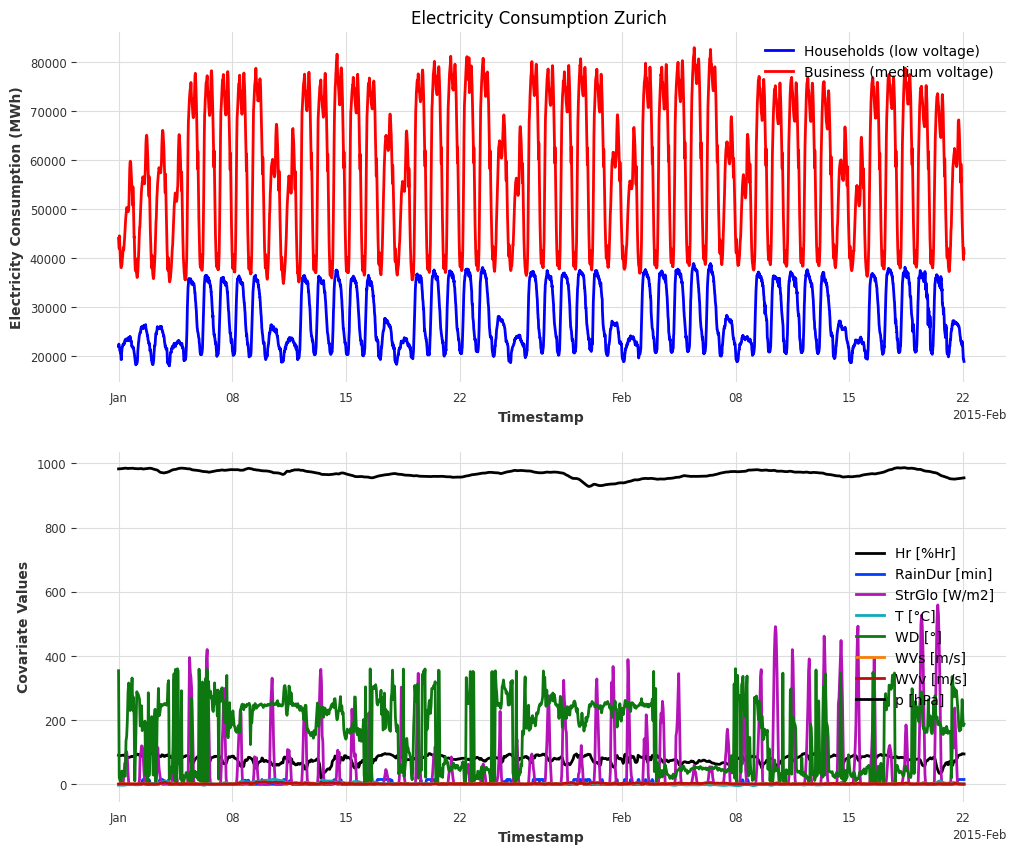

In [10]:
# Plot actual values on first subplot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
series["Value_NE5"][:5000].plot(label ="Households (low voltage)", color='blue', ax=ax1)
series["Value_NE7"][:5000].plot(label="Business (medium voltage)", color='red', title= "Electricity Consumption Zurich ", ax=ax1)
ax1.set_ylabel("Electricity Consumption (MWh)")
series[covariate_columns][:5000].plot( ax=ax2)
ax2.set_ylabel("Covariate Values")

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Preprocess the target and covariate time-series</h2>

1. split the time series into two different series
   `target_series`and `past_covariates`
2. try out different frequencies (half-hourly, hourly, daily). Keep in mind we are training deep learning models (data hungry).
2. preprocess both series using the exact same parameters

This exercise will help you understand how to deal with covariates.
</div>

In [11]:
# splt the time series into target and covariates
target_series = series[target_columns]
past_covariates = series[covariate_columns]

In [ ]:
train_target, val_target, test_target, scaler_target = preprocessing_data_with_DARTS(target_series,
                                              resample_freq='h', agg_method='sum',
                                              missing_strategy='linear', 
                                              scaling_method='standard',
                                              train_ratio=0.7, val_ratio=0.15)

train_past_cov, val_past_cov, test_past_cov, scaler_past_cov = preprocessing_data_with_DARTS(past_covariates,
                                              resample_freq='h', agg_method='sum',
                                              missing_strategy='linear', 
                                              scaling_method='standard',
                                              train_ratio=0.7, val_ratio=0.15)
                                                                                                    

# Adding future covariates to the data

Future covariates are known or predictable covariates into the future (e.g., holidays, planned events)


In [13]:
# adding future covariates to the data
from darts.utils.timeseries_generation import datetime_attribute_timeseries


preprocessed_series = train_target.append(val_target).append(test_target)

hour_series  = datetime_attribute_timeseries(preprocessed_series, attribute="hour", one_hot=False, cyclic=True)
dow_series   = datetime_attribute_timeseries(preprocessed_series, attribute="day_of_week", one_hot=True)
month_series = datetime_attribute_timeseries(preprocessed_series, attribute="month", one_hot=True)
future_covs  = hour_series.stack(dow_series).stack(month_series)

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Train an RNN model with and without covariates</h2>

1. Train an **RNN model** only on target series

2. Train an **RNN model** with the past and future covariate series
    Use both **past covariates** (weather data) and **future covariates** (time features)

3. Evaluate and compare the models using MAE, RMSE, MAPE and sMAPE metrics

6. Visualize the predictions vs actual values

</div>


In [14]:
from darts.models import BlockRNNModel

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### RNN model using only target series

In [ ]:
window_size = 24*3  # 3 days
forecast_horizon = 24  # one day
batch_size = 256
hidden_size = 64
n_rnn_layers = 2

model_simple = BlockRNNModel(model="RNN",
                input_chunk_length=window_size,
                hidden_dim=hidden_size, 
                n_rnn_layers=n_rnn_layers,
                batch_size=batch_size,
                output_chunk_length=forecast_horizon,
                random_state=42,
                pl_trainer_kwargs={"accelerator": "gpu"})

HINT: To calculate the training time use `time.time()` to get the python time.

In [16]:
# Train the model using only target series. Set the epochs to 2. calculate the training time.
start_time = time.time()

model_simple.fit(
    series=train_target,         
    val_series=val_target,    
    epochs=2,
    verbose=True)

end_time = time.time()
training_time_rnn_simple = end_time - start_time

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | RNN              | 12.7 K | train
6 | fc              | Sequential       | 130    | train
-------------------------------------------------------------
12.8 K    Trainable params
0         Non-trainable params
12.8 K    Total params
0.051     Total estimated mo

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1: 100%|██████████| 184/184 [00:04<00:00, 37.08it/s, train_loss=0.229, val_loss=0.120]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 184/184 [00:04<00:00, 37.07it/s, train_loss=0.229, val_loss=0.120]


In [17]:
# Make predictions on the test set (use the historical_forecasts method)
 
pred_series_rnn_simple = model_simple.historical_forecasts(series=test_target,
                                            forecast_horizon=forecast_horizon, 
                                            retrain=False, 
                                            last_points_only=True)

# Inverse transform the predictions and actuals
pred_series_rnn_simple_unscaled = scaler_target.inverse_transform(pred_series_rnn_simple)
test_series_unscaled = scaler_target.inverse_transform(test_target)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [18]:
from darts.metrics import mae, rmse, mape, smape
# calculate evaluation metrics

evaluation_metrics_simple_rnn = {
    "MAE": mae(pred_series_rnn_simple_unscaled, test_series_unscaled),
    "RMSE": rmse(pred_series_rnn_simple_unscaled, test_series_unscaled),
    "MAPE": mape(pred_series_rnn_simple_unscaled, test_series_unscaled),
    "sMAPE": smape(pred_series_rnn_simple_unscaled, test_series_unscaled),
}

#### RNN model using past and future covariates

In [ ]:
# keep the same parameters as the simple RNN 
model_cov = BlockRNNModel(model="RNN",
                input_chunk_length=window_size,
                hidden_dim=hidden_size, 
                n_rnn_layers=n_rnn_layers,
                batch_size=batch_size,
                output_chunk_length=forecast_horizon,
                random_state=42,
                pl_trainer_kwargs={"accelerator": "gpu"})

In [21]:
# Train the model using only target series. Set the epochs to 2. calculate the training time.
start_time = time.time()

model_cov.fit(
    series=train_target,         
    val_series=val_target,
    past_covariates=train_past_cov,
    val_past_covariates=val_past_cov,
    future_covariates=future_covs, 
    val_future_covariates=future_covs,       
    epochs=2,
    verbose=True)

end_time = time.time()
training_time_rnn_cov = end_time - start_time

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | RNN              | 14.5 K | train
6 | fc              | Sequential       | 172    | train
-------------------------------------------------------------
14.7 K    Trainable params
0         Non-trainable params
14.7 K    Total params
0.059     Total estimated mo

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1: 100%|██████████| 184/184 [00:05<00:00, 33.79it/s, train_loss=0.0211, val_loss=0.047] 

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 184/184 [00:05<00:00, 33.79it/s, train_loss=0.0211, val_loss=0.047]


In [22]:
# Make predictions on the test set (use the historical_forecasts method)

pred_series_rnn_cov = model_cov.historical_forecasts(series=test_target,
                                                    past_covariates=test_past_cov,
                                                    future_covariates=future_covs,
                                                    forecast_horizon=forecast_horizon, 
                                                    retrain=False, 
                                                    last_points_only=True)

# Inverse transform the predictions and actuals
pred_series_rnn_cov_unscaled = scaler_target.inverse_transform(pred_series_rnn_cov)
test_series_unscaled = scaler_target.inverse_transform(test_target)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [23]:
# calculate evaluation metrics

evaluation_metrics_cov_rnn = {
    "MAE": mae(pred_series_rnn_cov_unscaled, test_series_unscaled),
    "RMSE": rmse(pred_series_rnn_cov_unscaled, test_series_unscaled),
    "MAPE": mape(pred_series_rnn_cov_unscaled, test_series_unscaled),
    "sMAPE": smape(pred_series_rnn_cov_unscaled, test_series_unscaled),
}

In [24]:
print("RNN with past and future covariates:", evaluation_metrics_cov_rnn)
print("\n")
print("Training time RNN with covariates (seconds):", training_time_rnn_cov)
print("\n")
print("################################")
print("\n") 
print("RNN without covariates:", evaluation_metrics_simple_rnn)
print("\n")
print("Training time RNN without covariates (seconds):", training_time_rnn_simple)

RNN with past and future covariates: {'MAE': 5414.2425924684485, 'RMSE': 7519.021356732171, 'MAPE': 3.7148914921807488, 'sMAPE': 3.725575067323403}


Training time RNN with covariates (seconds): 10.99520993232727


################################


RNN without covariates: {'MAE': 8431.384410074294, 'RMSE': 11280.159547356729, 'MAPE': 5.755129967193559, 'sMAPE': 5.635837587672342}


Training time RNN without covariates (seconds): 10.189285039901733


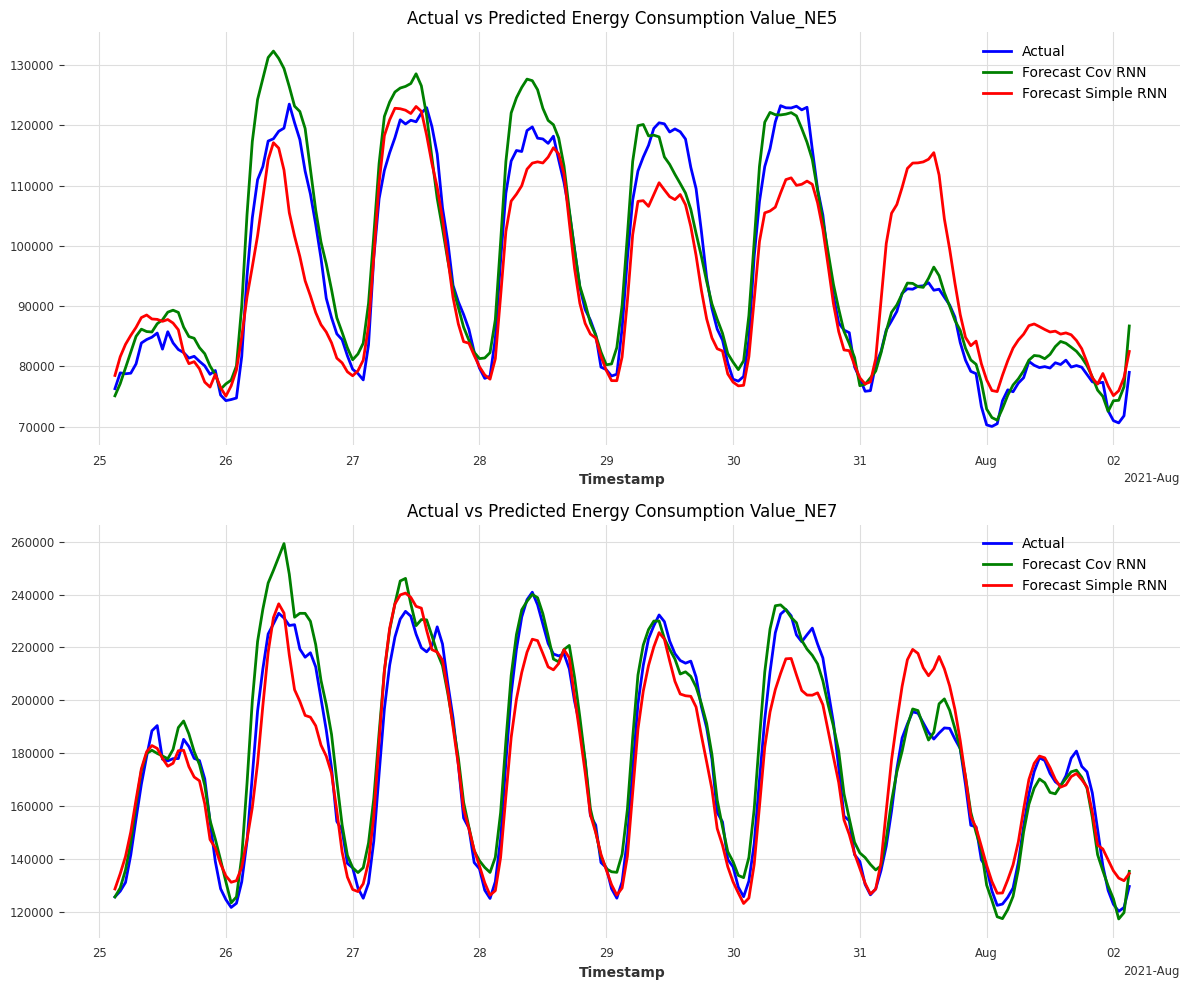

In [25]:
# Plotting some predictions vs actuals
start_idx = pd.Timestamp('2021-07-25 03:00:00')
end_idx = pd.Timestamp('2021-08-02 03:00:00')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
test_series_unscaled[target_columns[0]][start_idx:end_idx].plot(label="Actual", color='blue', ax=ax1)
pred_series_rnn_cov_unscaled[target_columns[0]][start_idx:end_idx].plot(label="Forecast Cov RNN", color='green', ax=ax1)
pred_series_rnn_simple_unscaled[target_columns[0]][start_idx:end_idx].plot(label="Forecast Simple RNN", color='red', title=f"Actual vs Predicted Energy Consumption {target_columns[0]}", ax=ax1)

test_series_unscaled[target_columns[1]][start_idx:end_idx].plot(label="Actual", color='blue', ax=ax2)
pred_series_rnn_cov_unscaled[target_columns[1]][start_idx:end_idx].plot(label="Forecast Cov RNN", color='green', ax=ax2)
pred_series_rnn_simple_unscaled[target_columns[1]][start_idx:end_idx].plot(label="Forecast Simple RNN", color='red', title=f"Actual vs Predicted Energy Consumption {target_columns[1]}", ax=ax2)

ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show()

Now we will explore the implementation of modern deep learning architectures for time series forecasting using the Darts library. In this section, we'll compare three powerful approaches:

### **Variants of Recurrent Neural Networks (RNN)**
- **GRU (Gated Recurrent Unit)**: A simplified LSTM variant that captures temporal dependencies
- **LSTM (Long Short-Term Memory)**: Classic architecture for sequential data with memory cells

### **Temporal Convolutional Networks (TCN)**
- **Key advantage**: Parallelizable training (unlike RNNs)
- **Receptive field**: Controlled by kernel size and dilation patterns
- **Best for**: Local patterns and seasonal dependencies

### **Transformer Models**
- **Attention mechanism**: Captures long-range dependencies efficiently
- **Context window**: Direct access to entire input sequence
- **Best for**: Complex temporal relationships and non-local patterns

Let's implement and compare these architectures:

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Train a LSTM, GRU, TCN models</h2>

1. Train an **LSTM model** using the preprocessed electricity consumption data

(Use both **past covariates** (weather data) and **future covariates** (time features))

2. Train a **GRU model** with the same parameters for comparison

(Use both **past covariates** (weather data) and **future covariates** (time features))

3. Train a **TCN model** and compare performance

(Use **past covariates** (weather data). Attention: TCN does not handle future covariates)

4. Evaluate and compare the models using sMAPE metrics

5. Visualize the predictions vs actual values

</div>


### RNN model

In [26]:
window_size = 24*3  # 3 days
forecast_horizon = 24  # one day
batch_size = 256
hidden_size = 64
n_rnn_layers = 2

In [27]:
# get the results variable from the last RNN model with covariates
model_rnn = model_cov
pred_series_rnn_unscaled = pred_series_rnn_cov_unscaled
evaluation_metrics_rnn = evaluation_metrics_cov_rnn
training_time_rnn = training_time_rnn_cov

### LTSM model

In [28]:
# LSTM model
model_lstm = BlockRNNModel(
        model="LSTM",
        input_chunk_length=window_size,
        hidden_dim=hidden_size, 
        n_rnn_layers=n_rnn_layers,
        batch_size=batch_size,
        output_chunk_length=forecast_horizon,
        random_state=42,
        pl_trainer_kwargs={"accelerator": "gpu"})

# Train the model using only target series. Set the epochs to 2. calculate the training time.
start_time = time.time()
model_lstm.fit(
    series=train_target,         
    val_series=val_target,
    past_covariates=train_past_cov,
    val_past_covariates=val_past_cov,
    future_covariates=future_covs, 
    val_future_covariates=future_covs,       
    epochs=2,
    verbose=True)
end_time = time.time()
training_time_lstm = end_time - start_time

# Make predictions on the test set (use the historical_forecasts method)
pred_series_lstm = model_lstm.historical_forecasts(series=test_target,
                                                    past_covariates=test_past_cov,
                                                    future_covariates=future_covs,
                                                    forecast_horizon=forecast_horizon, 
                                                    retrain=False, 
                                                    last_points_only=True)

# Inverse transform the predictions and actuals
pred_series_lstm_unscaled = scaler_target.inverse_transform(pred_series_lstm)

# calculate evaluation metrics
evaluation_metrics_lstm = {
    "MAE": mae(pred_series_lstm_unscaled, test_series_unscaled),
    "RMSE": rmse(pred_series_lstm_unscaled, test_series_unscaled),
    "MAPE": mape(pred_series_lstm_unscaled, test_series_unscaled),
    "sMAPE": smape(pred_series_lstm_unscaled, test_series_unscaled),
}

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 58.1 K | train
6 | fc              | Sequential       | 172    | train
-------------------------------------------------------------
58.3 K    Trainable params
0         Non-trainable params
58.3 K    Total params
0.233     Total estimated mo

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1: 100%|██████████| 184/184 [00:21<00:00,  8.61it/s, train_loss=0.0267, val_loss=0.0583]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 184/184 [00:21<00:00,  8.61it/s, train_loss=0.0267, val_loss=0.0583]

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


### GRU

In [29]:
# GRU model
model_gru = BlockRNNModel(
        model="GRU",
        input_chunk_length=window_size,
        hidden_dim=hidden_size, 
        n_rnn_layers=n_rnn_layers,
        batch_size=batch_size,
        output_chunk_length=forecast_horizon,
        random_state=42,
        pl_trainer_kwargs={"accelerator": "gpu"})

# Train the model using only target series. Set the epochs to 2. calculate the training time.
start_time = time.time()
model_gru.fit(
    series=train_target,         
    val_series=val_target,
    past_covariates=train_past_cov,
    val_past_covariates=val_past_cov,
    future_covariates=future_covs, 
    val_future_covariates=future_covs,       
    epochs=2,
    verbose=True)
end_time = time.time()
training_time_gru= end_time - start_time

# Make predictions on the test set (use the historical_forecasts method)
pred_series_gru = model_gru.historical_forecasts(series=test_target,
                                                    past_covariates=test_past_cov,
                                                    future_covariates=future_covs,
                                                    forecast_horizon=forecast_horizon, 
                                                    retrain=False, 
                                                    last_points_only=True)

# Inverse transform the predictions and actuals
pred_series_gru_unscaled = scaler_target.inverse_transform(pred_series_gru)

# calculate evaluation metrics
evaluation_metrics_gru = {
    "MAE": mae(pred_series_gru_unscaled, test_series_unscaled),
    "RMSE": rmse(pred_series_gru_unscaled, test_series_unscaled),
    "MAPE": mape(pred_series_gru_unscaled, test_series_unscaled),
    "sMAPE": smape(pred_series_gru_unscaled, test_series_unscaled),
}

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | GRU              | 43.6 K | train
6 | fc              | Sequential       | 172    | train
-------------------------------------------------------------
43.8 K    Trainable params
0         Non-trainable params
43.8 K    Total params
0.175     Total estimated mo

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1: 100%|██████████| 184/184 [00:17<00:00, 10.28it/s, train_loss=0.033, val_loss=0.0395] 

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 184/184 [00:17<00:00, 10.28it/s, train_loss=0.033, val_loss=0.0395]


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


### TCN

#### TCN Model Architecture:

- Temporal Convolutional Network with dilated causal convolutions

- Parallelizable training (unlike RNNs)

- Receptive field controlled by kernel size and dilation patterns

- Residual connections and dropout for regularization

**Example Implementation:**

```python
from darts.models import TCNModel

model_tcn = TCNModel(
    input_chunk_length=window_size,     # 168 timesteps lookback (1 week)
    output_chunk_length=forecast_horizon, # 24 timesteps forecast (1 day)
    kernel_size=5,                      # Convolutional kernel size
    num_filters=64,                     # Number of filters per layer
    num_layers=3,                       # Number of TCN layers
    dilation_base=2,                    # Exponential dilation factor
    batch_size=256,                     # Batch size for training
    pl_trainer_kwargs={"accelerator": "gpu"},
    random_state=42,
)
```
**What’s happening**:
kernel_size=5: Size of the 1D convolutional kernel. Controls local pattern detection.

💡 Larger kernels capture longer local dependencies but increase parameters.

num_filters=64: Number of convolutional filters per layer (width of the network).

💡 More filters → more capacity to learn diverse temporal patterns.

num_layers=3: Depth of the TCN (number of dilated conv blocks stacked).

💡 More layers increase the receptive field exponentially with dilations.

dilation_base=2: Exponential growth factor for dilations (1, 2, 4, 8, ...).

💡 Higher base → faster growth of receptive field but potential gaps in coverage.

In [30]:
from darts.models import TCNModel  

In [31]:

# TCN model
model_tcn = TCNModel(input_chunk_length=window_size,
                output_chunk_length=forecast_horizon,
                kernel_size=5,
                num_filters=5,
                num_layers=3,
                dilation_base=2,
                batch_size=256,
                pl_trainer_kwargs={"accelerator": "gpu"},
                random_state=42,
                )

# Train the model using only target series. Set the epochs to 2. calculate the training time.
start_time = time.time()
model_tcn.fit(
    series=train_target,         
    val_series=val_target,
    past_covariates=train_past_cov,
    val_past_covariates=val_past_cov,
    epochs=2,
    verbose=True)
end_time = time.time()
training_time_tcn = end_time - start_time

# Make predictions on the test set (use the historical_forecasts method)
pred_series_tcn = model_tcn.historical_forecasts(series=test_target,
                                                    past_covariates=test_past_cov,
                                                    forecast_horizon=forecast_horizon, 
                                                    retrain=False, 
                                                    last_points_only=True)

# Inverse transform the predictions and actuals
pred_series_tcn_unscaled = scaler_target.inverse_transform(pred_series_tcn)

# calculate evaluation metrics
evaluation_metrics_tcn = {
    "MAE": mae(pred_series_tcn_unscaled, test_series_unscaled),
    "RMSE": rmse(pred_series_tcn_unscaled, test_series_unscaled),
    "MAPE": mape(pred_series_tcn_unscaled, test_series_unscaled),
    "sMAPE": smape(pred_series_tcn_unscaled, test_series_unscaled),
}

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 894    | train
-------------------------------------------------------------
894       Trainable params
0         Non-trainable params
894       Total params
0.004     Total estimated model params size (MB)
23        Modules in train mode
0  

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1: 100%|██████████| 184/184 [00:09<00:00, 19.69it/s, train_loss=0.277, val_loss=0.194]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 184/184 [00:09<00:00, 19.69it/s, train_loss=0.277, val_loss=0.194]

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [32]:
print("RNN:", evaluation_metrics_rnn)
print("Training time RNN(seconds):", training_time_rnn)
print("\n")
print("################################")
print("\n") 
print("LSTM:", evaluation_metrics_lstm)
print("Training time LSTM (seconds):", training_time_lstm)
print("\n")
print("################################")
print("\n") 
print("GRU:", evaluation_metrics_gru)
print("Training time GRU (seconds):", training_time_gru)
print("\n")
print("################################")
print("\n") 
print("TCN:", evaluation_metrics_tcn)
print("Training time TCN (seconds):", training_time_tcn)    

RNN: {'MAE': 5414.2425924684485, 'RMSE': 7519.021356732171, 'MAPE': 3.7148914921807488, 'sMAPE': 3.725575067323403}
Training time RNN(seconds): 10.99520993232727


################################


LSTM: {'MAE': 6829.919373674606, 'RMSE': 8946.3250207556, 'MAPE': 4.40998112345086, 'sMAPE': 4.462410675887707}
Training time LSTM (seconds): 43.05480599403381


################################


GRU: {'MAE': 4908.301171667692, 'RMSE': 6891.235532880795, 'MAPE': 3.425719163867253, 'sMAPE': 3.4260930964993928}
Training time GRU (seconds): 35.88498902320862


################################


TCN: {'MAE': 11307.178396709425, 'RMSE': 14912.913605641605, 'MAPE': 7.358607408277489, 'sMAPE': 7.519383184735252}
Training time TCN (seconds): 18.633844137191772


<Axes: title={'center': 'Actual vs Predicted Energy Consumption Value_NE7'}, xlabel='Timestamp'>

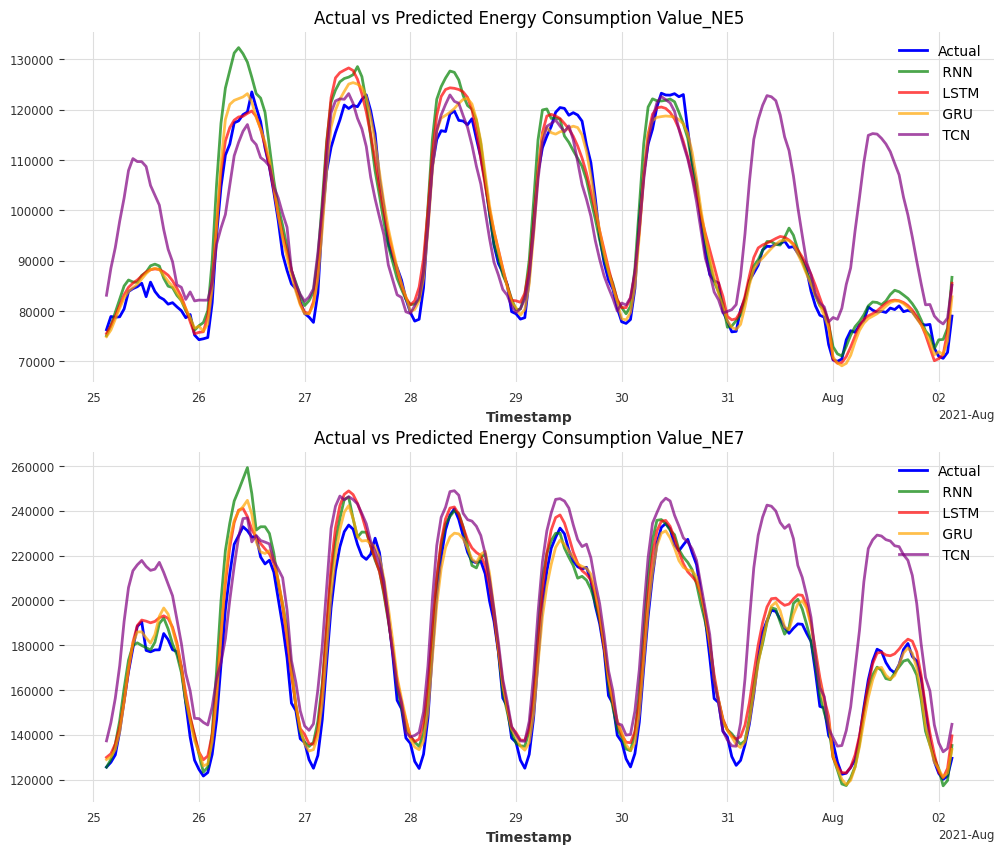

In [33]:
# plotting some predictions vs actuals
start_idx = pd.Timestamp('2021-07-25 03:00:00')
end_idx = pd.Timestamp('2021-08-02 03:00:00')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
test_series_unscaled[target_columns[0]][start_idx:end_idx].plot(label="Actual", color='blue', ax=ax1)
pred_series_rnn_unscaled[target_columns[0]][start_idx:end_idx].plot(label=" RNN", color='green', ax=ax1, alpha=0.7)
pred_series_lstm_unscaled[target_columns[0]][start_idx:end_idx].plot(label=" LSTM", color='red', ax=ax1, alpha=0.7)
pred_series_gru_unscaled[target_columns[0]][start_idx:end_idx].plot(label=" GRU", color='orange', ax=ax1, alpha=0.7)
pred_series_tcn_unscaled[target_columns[0]][start_idx:end_idx].plot(label=" TCN", color='purple', alpha=0.7, title=f"Actual vs Predicted Energy Consumption {target_columns[0]}", ax=ax1)

test_series_unscaled[target_columns[1]][start_idx:end_idx].plot(label="Actual", color='blue', ax=ax2)
pred_series_rnn_unscaled[target_columns[1]][start_idx:end_idx].plot(label=" RNN", color='green', ax=ax2, alpha=0.7)
pred_series_lstm_unscaled[target_columns[1]][start_idx:end_idx].plot(label=" LSTM", color='red', ax=ax2, alpha=0.7)
pred_series_gru_unscaled[target_columns[1]][start_idx:end_idx].plot(label=" GRU", color='orange', ax=ax2, alpha=0.7)
pred_series_tcn_unscaled[target_columns[1]][start_idx:end_idx].plot(label=" TCN", color='purple', alpha=0.7, title=f"Actual vs Predicted Energy Consumption {target_columns[1]}", ax=ax2)


<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise (Optional): Train Transformer/ARIMA/Prophet with DARTS</h2>

In this optional exercise, you'll explore additional forecasting approaches to complete your comparison:

### **Transformer Model**
1. Train a **Transformer model** using past covariates (weather data) (Attention: future covariates not supported)
2. Configure the attention mechanism with appropriate parameters:
   - `d_model`: Embedding dimension (64)
   - `nhead`: Number of attention heads (4) 
   - `num_encoder_layers` and `num_decoder_layers`: Network depth (2 each)

### **ARIMA Model (Classical Statistical)**
3. Train **ARIMA models** for time series forecasting
   - **Note**: ARIMA only supports univariate series, so train separate models for each target
   - Combine predictions from both models for evaluation

### **Prophet Model (Facebook's Forecasting Tool)**
4. Train a **Prophet model** with seasonality components:
   - Enable daily, weekly, and yearly seasonality
   - Use future covariates (time faeatures) to improve predictions

### **Evaluation & Comparison**
5. Compare all models using the same metrics (MAE, RMSE, MAPE, sMAPE)
6. Analyze training times and performance trade-offs
7. Visualize predictions to understand each model's behavior

**Learning Goals:**
- Understand when to use classical vs. modern approaches
- Compare attention mechanisms (Transformer) vs. convolutions (TCN) vs. recurrence (RNN/LSTM/GRU)
- See how statistical models (ARIMA/Prophet) perform against deep learning approaches
- Learn about multivariate forecasting strategies with univariate models

</div>

In [29]:
from darts.models import TransformerModel

In [30]:
# Transformer model
model_transformer = TransformerModel(input_chunk_length=window_size,
                        output_chunk_length=forecast_horizon,
                        d_model=64, 
                        nhead=4, 
                        num_encoder_layers=2, 
                        num_decoder_layers=2,
                        dim_feedforward=128,
                        batch_size=256,
                        pl_trainer_kwargs={"accelerator": "gpu"},)

# Train the model using only target series. Set the epochs to 2. calculate the training time.
start_time = time.time()
model_transformer.fit(
    series=train_target,         
    val_series=val_target,
    past_covariates=train_past_cov,
    val_past_covariates=val_past_cov,
    epochs=2,
    verbose=True)
end_time = time.time()
training_time_transformer = end_time - start_time

# Make predictions on the test set (use the historical_forecasts method)
pred_series_transformer = model_transformer.historical_forecasts(series=test_target,
                                                    past_covariates=test_past_cov,
                                                    forecast_horizon=forecast_horizon, 
                                                    retrain=False, 
                                                    last_points_only=True)

# Inverse transform the predictions and actuals
pred_series_transformer_unscaled = scaler_target.inverse_transform(pred_series_transformer)

# calculate evaluation metrics
evaluation_metrics_transformer = {
    "MAE": mae(pred_series_transformer_unscaled, test_series_unscaled),
    "RMSE": rmse(pred_series_transformer_unscaled, test_series_unscaled),
    "MAPE": mape(pred_series_transformer_unscaled, test_series_unscaled),
    "sMAPE": smape(pred_series_transformer_unscaled, test_series_unscaled),
}

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name                | Type                | Params | Mode 
--------------------------------------------------------------------
0 | criterion           | MSELoss             | 0      | train
1 | train_criterion     | MSELoss             | 0      | train
2 | val_criterion       | MSELoss             | 0      | train
3 | train_metrics       | MetricCollecti

/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1: 100%|██████████| 184/184 [00:45<00:00,  4.08it/s, train_loss=0.138, val_loss=0.101]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 184/184 [00:45<00:00,  4.08it/s, train_loss=0.138, val_loss=0.101]


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


⚠️ ARIMA is too slow (computation hungry). To run this resample the data to the "d" frequency (daily)

In [63]:
from darts.models import ARIMA

start_time = time.time()

# ARIMA requires univariate series, so we train separate models for each target Model for Value_NE5 (Households)
print("Training ARIMA for Value_NE5 (Households)...")
train_ne5 = train_target["Value_NE5"]
test_ne5 = test_target["Value_NE5"]


model_arima_ne5 = ARIMA(p=2, d=1, q=2, seasonal_order=(1, 1, 1, 24))
model_arima_ne5.fit(train_ne5)

pred_arima_ne5 = model_arima_ne5.historical_forecasts(
    series=test_ne5,
    forecast_horizon=forecast_horizon,
    retrain=False,
    last_points_only=True
)

# Model for Value_NE7 (Business)
print("Training ARIMA for Value_NE7 (Business)...")
train_ne7 = train_target["Value_NE7"]
test_ne7 = test_target["Value_NE7"]

model_arima_ne7 = ARIMA(p=2, d=1, q=2, seasonal_order=(1, 1, 1, 24))
model_arima_ne7.fit(train_ne7)

pred_arima_ne7 = model_arima_ne7.historical_forecasts(
    series=test_ne7,
    forecast_horizon=forecast_horizon,
    retrain=False,
    last_points_only=True
)

end_time = time.time()
training_time_arima = end_time - start_time

# Combine the two predictions into a multivariate series
pred_series_arima = pred_arima_ne5.stack(pred_arima_ne7)

# Inverse transform predictions
pred_series_arima_unscaled = scaler_target.inverse_transform(pred_series_arima)
test_series_unscaled = scaler_target.inverse_transform(test_target)

# Calculate evaluation metrics
evaluation_metrics_arima = {
    "MAE": mae(pred_series_arima_unscaled, test_series_unscaled),
    "RMSE": rmse(pred_series_arima_unscaled, test_series_unscaled),
    "MAPE": mape(pred_series_arima_unscaled, test_series_unscaled),
    "sMAPE": smape(pred_series_arima_unscaled, test_series_unscaled),
}

Training ARIMA for Value_NE5 (Households)...


/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Training ARIMA for Value_NE7 (Business)...


/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [67]:
from darts.models import Prophet

In [77]:
# Train the Prophet model (univariate only)

start_time = time.time()

# Prophet requires univariate series, so we train separate models for each target
# Model for Value_NE5 (Households)
train_ne5 = train_target["Value_NE5"]
test_ne5 = test_target["Value_NE5"]

model_prophet_ne5 = Prophet()
model_prophet_ne5.fit(train_ne5)

pred_prophet_ne5 = model_prophet_ne5.historical_forecasts(
    series=test_ne5,
    forecast_horizon=forecast_horizon,
    retrain=True,
    last_points_only=True
)

# Model for Value_NE7 (Business)
print("Training Prophet for Value_NE7 (Business)...")
train_ne7 = train_target["Value_NE7"]
test_ne7 = test_target["Value_NE7"]

model_prophet_ne7 = Prophet()
model_prophet_ne7.fit(train_ne7)

pred_prophet_ne7 = model_prophet_ne7.historical_forecasts(
    series=test_ne7,
    forecast_horizon=forecast_horizon,
    retrain=True,
    last_points_only=True
)

end_time = time.time()
training_time_prophet = end_time - start_time

# Combine the two predictions into a multivariate series
pred_series_prophet = pred_prophet_ne5.stack(pred_prophet_ne7)

# Inverse transform predictions
pred_series_prophet_unscaled = scaler_target.inverse_transform(pred_series_prophet)

# Calculate evaluation metrics
evaluation_metrics_prophet = {
    "MAE": mae(pred_series_prophet_unscaled, test_series_unscaled),
    "RMSE": rmse(pred_series_prophet_unscaled, test_series_unscaled),
    "MAPE": mape(pred_series_prophet_unscaled, test_series_unscaled),
    "sMAPE": smape(pred_series_prophet_unscaled, test_series_unscaled),
}


21:31:45 - cmdstanpy - INFO - Chain [1] start processing
21:31:45 - cmdstanpy - INFO - Chain [1] done processing
21:31:45 - cmdstanpy - INFO - Chain [1] start processing
21:31:45 - cmdstanpy - INFO - Chain [1] done processing
21:31:45 - cmdstanpy - INFO - Chain [1] start processing
21:31:45 - cmdstanpy - INFO - Chain [1] done processing
21:31:45 - cmdstanpy - INFO - Chain [1] start processing
21:31:45 - cmdstanpy - INFO - Chain [1] done processing
21:31:45 - cmdstanpy - INFO - Chain [1] start processing
21:31:45 - cmdstanpy - INFO - Chain [1] done processing
21:31:45 - cmdstanpy - INFO - Chain [1] start processing
21:31:45 - cmdstanpy - INFO - Chain [1] done processing
21:31:46 - cmdstanpy - INFO - Chain [1] start processing
21:31:46 - cmdstanpy - INFO - Chain [1] done processing
21:31:46 - cmdstanpy - INFO - Chain [1] start processing
21:31:46 - cmdstanpy - INFO - Chain [1] done processing
21:31:46 - cmdstanpy - INFO - Chain [1] start processing
21:31:46 - cmdstanpy - INFO - Chain [1]

Training Prophet for Value_NE7 (Business)...


21:32:12 - cmdstanpy - INFO - Chain [1] done processing
21:32:12 - cmdstanpy - INFO - Chain [1] start processing
21:32:12 - cmdstanpy - INFO - Chain [1] done processing
21:32:12 - cmdstanpy - INFO - Chain [1] start processing
21:32:12 - cmdstanpy - INFO - Chain [1] done processing
21:32:12 - cmdstanpy - INFO - Chain [1] start processing
21:32:12 - cmdstanpy - INFO - Chain [1] done processing
21:32:12 - cmdstanpy - INFO - Chain [1] start processing
21:32:13 - cmdstanpy - INFO - Chain [1] done processing
21:32:13 - cmdstanpy - INFO - Chain [1] start processing
21:32:13 - cmdstanpy - INFO - Chain [1] done processing
21:32:13 - cmdstanpy - INFO - Chain [1] start processing
21:32:13 - cmdstanpy - INFO - Chain [1] done processing
21:32:13 - cmdstanpy - INFO - Chain [1] start processing
21:32:13 - cmdstanpy - INFO - Chain [1] done processing
21:32:13 - cmdstanpy - INFO - Chain [1] start processing
21:32:13 - cmdstanpy - INFO - Chain [1] done processing
21:32:13 - cmdstanpy - INFO - Chain [1] 

In [78]:
# Print comprehensive comparison of all models
print("=" * 60)
print("MODEL COMPARISON RESULTS")
print("=" * 60)

models_results = {
    "RNN": (evaluation_metrics_rnn, training_time_rnn),
    "LSTM": (evaluation_metrics_lstm, training_time_lstm),
    "GRU": (evaluation_metrics_gru, training_time_gru),
    "TCN": (evaluation_metrics_tcn, training_time_tcn),
    "Transformer": (evaluation_metrics_transformer, training_time_transformer),
    "ARIMA": (evaluation_metrics_arima, training_time_arima),
    "Prophet": (evaluation_metrics_prophet, training_time_prophet)
}

for model_name, (metrics, train_time) in models_results.items():
    print(f"\n{model_name}:")
    print(f"  sMAPE: {metrics['sMAPE']:.4f}")
    print(f"  MAE:   {metrics['MAE']:.4f}")
    print(f"  RMSE:  {metrics['RMSE']:.4f}")
    print(f"  Training Time: {train_time:.2f}s")
    print("-" * 40)  

MODEL COMPARISON RESULTS

RNN:
  sMAPE: 3.7256
  MAE:   5414.2426
  RMSE:  7519.0214
  Training Time: 10.72s
----------------------------------------

LSTM:
  sMAPE: 4.4624
  MAE:   6829.9194
  RMSE:  8946.3250
  Training Time: 46.04s
----------------------------------------

GRU:
  sMAPE: 3.4261
  MAE:   4908.3012
  RMSE:  6891.2355
  Training Time: 37.34s
----------------------------------------

TCN:
  sMAPE: 7.5194
  MAE:   11307.1784
  RMSE:  14912.9136
  Training Time: 18.82s
----------------------------------------

Transformer:
  sMAPE: 5.6878
  MAE:   8404.3881
  RMSE:  11139.7360
  Training Time: 90.88s
----------------------------------------

ARIMA:
  sMAPE: 9.0819
  MAE:   317658.8633
  RMSE:  427870.2972
  Training Time: 92.83s
----------------------------------------

Prophet:
  sMAPE: 6.9847
  MAE:   257793.3385
  RMSE:  650821.5245
  Training Time: 54.74s
----------------------------------------



## Discussion — Practical Takeaways
- **When to prefer TCN?** When parallelism matters and seasonal/local patterns over medium-to-long contexts dominate.
- **When to prefer Transformer?** When long-range, non-local dependencies are key (mind the memory cost of large context windows).
- **When to prefer GRU/LSTM?** With smaller datasets/models and moderate context lengths; often stable and efficient.
- **Hyperparameters mapping:** `window_size` ≈ context length. For TCN, the **receptive field** (kernel size, dilations, stacks) sets the effective context.
